# **Redes Bayesianas para vuelos seguros de drones**

In [ ]:
if (!requireNamespace("bnlearn", quietly = TRUE)) install.packages("bnlearn")
if (!requireNamespace("gRain", quietly = TRUE))   install.packages("gRain")
library(bnlearn); library(gRain)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gRbase’, ‘igraph’, ‘RcppArmadillo’, ‘RcppEigen’


Loading required package: gRbase


Attaching package: ‘gRbase’


The following objects are masked from ‘package:bnlearn’:

    ancestors, children, nodes, parents




In [ ]:
set.seed(123)

# 1) Generación de datos sintéticos (todo DISCRETO)

**DAG natural:**
$$ \text{Condiciones climáticas} \longrightarrow Y $$

**Modelo causal base:**
$$ V_{\text{wind}},\ T,\ H,\ V_{\text{vis}} \longrightarrow Y $$

**Donde:**
- $V_{\text{wind}}$: Velocidad del viento
- $T$: Temperatura
- $H$: Humedad
- $V_{\text{vis}}$: Visibilidad vertical
- $Y$: Seguridad de vuelo (variable objetivo)


In [ ]:
#tamaño muestral
N <- 3000

**Variables climáticas (todas discretas)**

**Velocidad del viento ($V_{wind}$):**

**Categorías:** baja, moderada, alta

**Hipótesis:**
- $20\%$ baja
- $50\%$ moderada  
- $30\%$ alta

In [ ]:
Vwind <- factor(sample(c("baja","moderada","alta"), N, replace=TRUE, prob=c(0.2,0.5,0.3)))

**Temperatura ($T$):**

**Categorías:** baja, media, alta

**Hipótesis:**
- $25\%$ baja
- $50\%$ media  
- $25\%$ alta

In [ ]:
T <- factor(sample(c("baja","media","alta"), N, replace=TRUE, prob=c(0.25,0.5,0.25)))

**Humedad relativa ($H$):**

**Categorías:** baja, media, alta

**Hipótesis:**
- $30\%$ baja
- $40\%$ media  
- $30\%$ alta

In [ ]:
H <- factor(sample(c("baja","media","alta"), N, replace=TRUE, prob=c(0.3,0.4,0.3)))

**Visibilidad ($V_{vis}$):**

**Categorías:** buena, regular, baja

**Hipótesis:**
- $50\%$ buena
- $30\%$ regular  
- $20\%$ baja

In [ ]:
Vvis <- factor(sample(c("buena","regular","baja"), N, replace=TRUE, prob=c(0.5,0.3,0.2)))

**Variable crítica: Seguridad del vuelo ($Y$)**

**Cálculo a partir de una combinación logística de las variables causales.**

**Explicación causal:**

- Viento alto $\rightarrow$ reduce seguridad
- Temperatura alta o baja extrema $\rightarrow$ reduce batería o estabilidad  
- Humedad alta $\rightarrow$ daña electrónica
- Visibilidad baja $\rightarrow$ impide vuelo visual

In [ ]:
linY <- -2.0 +
  1.0*(Vwind=="moderada") + 0.5*(Vwind=="baja") +
  0.8*(T=="media") - 0.8*(T=="alta") - 0.6*(T=="baja") +
  -0.9*(H=="alta") + 0.2*(H=="media") +
  1.0*(Vvis=="buena") + 0.4*(Vvis=="regular")

prY <- plogis(linY)
Y <- factor(rbinom(N, 1, prY), labels=c("no_seguro","seguro"))


Construccion del dataset

In [ ]:
dataset <- data.frame(Vwind, T, H, Vvis, Y)
str(dataset)

'data.frame':	3000 obs. of  5 variables:
 $ Vwind: Factor w/ 3 levels "alta","baja",..: 3 3 3 2 2 1 1 2 1 1 ...
 $ T    : Factor w/ 3 levels "alta","baja",..: 2 2 2 2 3 2 1 3 3 3 ...
 $ H    : Factor w/ 3 levels "alta","baja",..: 1 1 2 1 1 3 3 2 2 2 ...
 $ Vvis : Factor w/ 3 levels "baja","buena",..: 3 2 2 2 3 2 2 2 3 2 ...
 $ Y    : Factor w/ 2 levels "no_seguro","seguro": 1 1 1 1 1 1 1 1 1 1 ...


**2) Aprendizaje de la red (estructura y parámetros)**

**Listas blanca/negra guiadas por conocimiento causal:**

**Lista blanca:**
$$V_{wind} \rightarrow Y,\quad T \rightarrow Y,\quad H \rightarrow Y,\quad V_{vis} \rightarrow Y$$

**Lista negra:**
$$Y \rightarrow V_{wind},\quad Y \rightarrow T,\quad Y \rightarrow H,\quad Y \rightarrow V_{vis}$$

**Restricciones causales:**
- Las variables climáticas influyen en $Y$
- $Y$ no causa a las variables climáticas

In [ ]:
wh <- data.frame(
  from=c("Vwind","T","H","Vvis"),
  to  =c("Y","Y","Y","Y")
)

bl <- data.frame(
  from=c("Y","Y","Y","Y"),
  to  =c("Vwind","T","H","Vvis")
)

bn <- hc(dataset, whitelist=wh, blacklist=bl, score="bic")
fit <- bn.fit(bn, dataset)
bn


  Bayesian network learned via Score-based methods

  model:
   [Vwind][T][H][Vvis][Y|Vwind:T:H:Vvis] 
  nodes:                                 5 
  arcs:                                  4 
    undirected arcs:                     0 
    directed arcs:                       4 
  average markov blanket size:           4.00 
  average neighbourhood size:            1.60 
  average branching factor:              0.80 

  learning algorithm:                    Hill-Climbing 
  score:                                 BIC (disc.) 
  penalization coefficient:              4.003184 
  tests used in the learning procedure:  10 
  optimized:                             TRUE 


**3) Inferencia what-if (aproximación do-calculus)**

**Queremos comparar:**

$$P(Y = \text{seguro} \mid \text{do}(V_{wind} = \text{baja}))$$

$$\text{vs}$$

$$P(Y = \text{seguro} \mid \text{do}(V_{wind} = \text{alta}))$$

**Objetivo:** Estimar el efecto causal del viento sobre la seguridad de vuelo

In [ ]:
gr <- as.grain(fit)

p_lowwind  <- querygrain(setEvidence(gr, nodes="Vwind", states=list(Vwind="baja")),  nodes="Y")$Y["seguro"]
p_highwind <- querygrain(setEvidence(gr, nodes="Vwind", states=list(Vwind="alta")), nodes="Y")$Y["seguro"]

delta_pp <- as.numeric(p_lowwind - p_highwind) * 100
delta_pp

[1] 10.66195

**Interpretación del resultado:**

El resultado $\Delta_{pp}$ expresa el aumento porcentual en la probabilidad de vuelo seguro al pasar de viento alto a bajo.

$$\Delta_{pp} = P(Y = \text{seguro} \mid \text{do}(V_{wind} = \text{baja})) - P(Y = \text{seguro} \mid \text{do}(V_{wind} = \text{alta}))$$

**4) Diagramas especializados**

**Herramientas de visualización:**
- **dagitty** para análisis de caminos causales
- **ggdag** para visualización en ggplot2
- **graphviz** para diagramas estructurales

**Objetivo:** Representar y validar la estructura causal del DAG

In [ ]:
if (!requireNamespace("dagitty", quietly = TRUE)) install.packages("dagitty")
if (!requireNamespace("ggplot2", quietly = TRUE)) install.packages("ggplot2")
if (!requireNamespace("ggdag", quietly = TRUE))    install.packages("ggdag")
library(dagitty); library(ggplot2); library(ggdag)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘V8’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘tweenr’, ‘polyclip’, ‘gridExtra’, ‘ggforce’, ‘viridis’, ‘graphlayouts’, ‘ggraph’, ‘ggrepel’, ‘tidygraph’



Attaching package: ‘dagitty’


The following objects are masked from ‘package:gRbase’:

    ancestors, children, edges, moralize, parents


The following objects are masked from ‘package:bnlearn’:

    ancestors, children, descendants, parents, spouses



Attaching package: ‘ggdag’


The following object is masked from ‘package:gRbase’:

    dag


The following object is masked from ‘package:stats’:

    filter




4.1 DAG causal (estático)

 {}

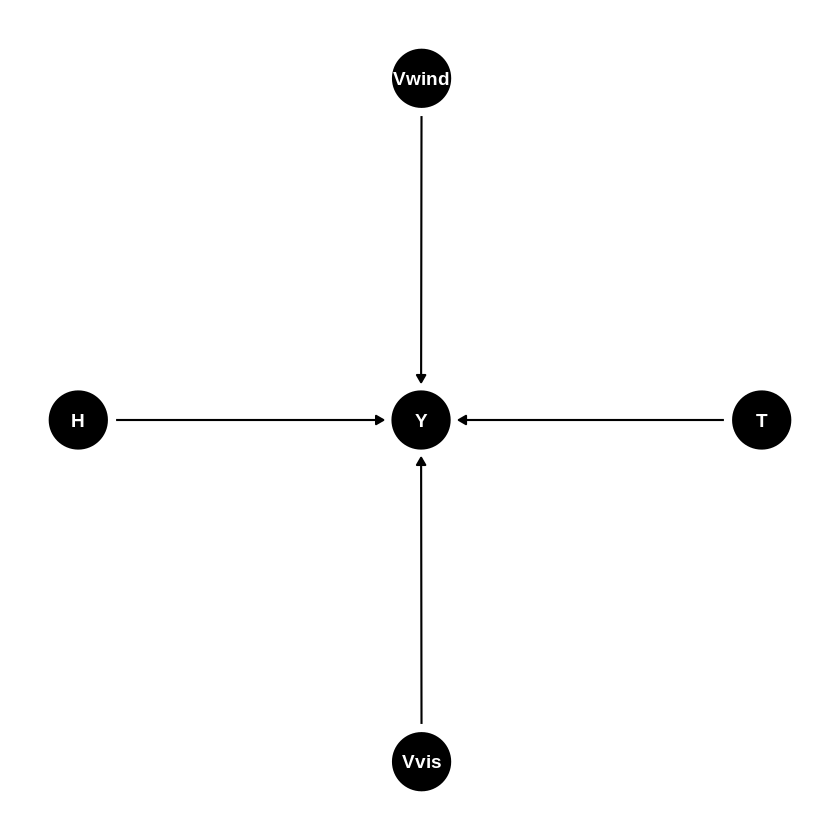

In [ ]:
g <- dagitty('
dag {
  Vwind T H Vvis Y
  Vwind -> Y
  T -> Y
  H -> Y
  Vvis -> Y
}
')

adjustmentSets(g, exposure="Vwind", outcome="Y")

set.seed(1)
tidy_dagitty(g) |>
  ggplot(aes(x=x,y=y,xend=xend,yend=yend)) +
  geom_dag_edges() +
  geom_dag_point() +
  geom_dag_text(size=4) +
  theme_dag()


4.2 Notación de placas (vuelo $i$, instante $t$)

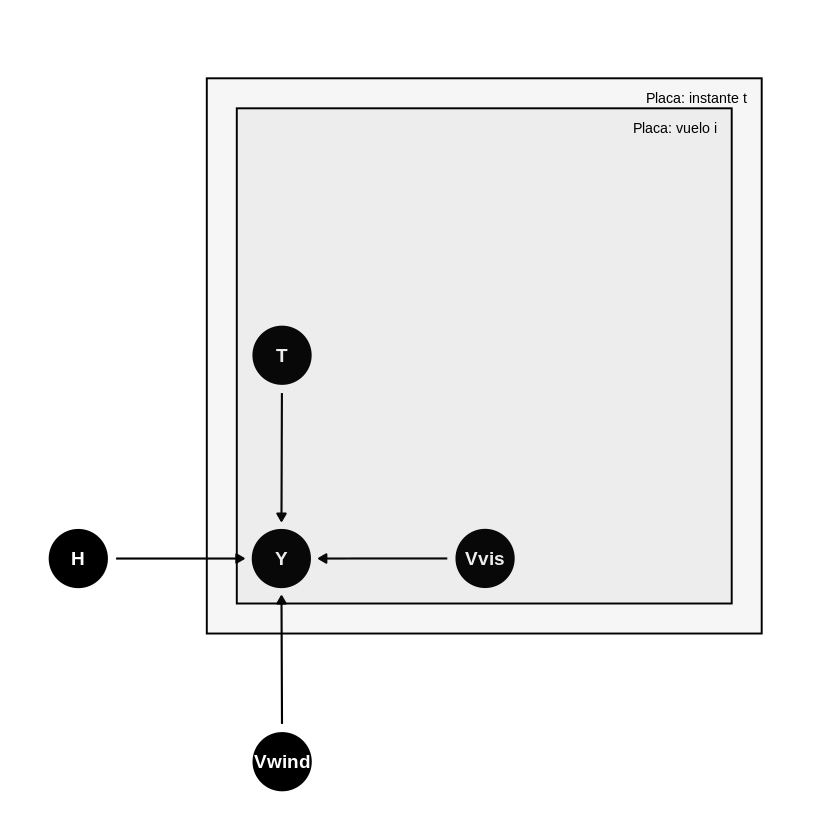

In [ ]:
p <- tidy_dagitty(g) |>
  ggplot(aes(x=x,y=y,xend=xend,yend=yend)) +
  geom_dag_edges() +
  geom_dag_point() +
  geom_dag_text(size=4) +
  theme_dag()

p +
  annotate("rect", xmin=-0.5, xmax=3.2, ymin=-0.5, ymax=3.2, alpha=0.05, color="black") +
  annotate("text", x=3.1, y=3.1, label="Placa: instante t", hjust=1, vjust=1, size=3) +
  annotate("rect", xmin=-0.3, xmax=3.0, ymin=-0.3, ymax=3.0, alpha=0.05, color="black") +
  annotate("text", x=2.9, y=2.9, label="Placa: vuelo i", hjust=1, vjust=1, size=3)


4.3 Visualización del DAG aprendido

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.21 (BiocManager 1.30.26), R 4.5.1 (2025-06-13)

Installing package(s) 'BiocVersion', 'Rgraphviz'

also installing the dependencies ‘BiocGenerics’, ‘graph’


Loading required package: graph

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:gRbase’:

    compile, fit


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:bnlearn’:

    score


The following objects are masked from ‘package:stats’:

    IQR, mad, sd

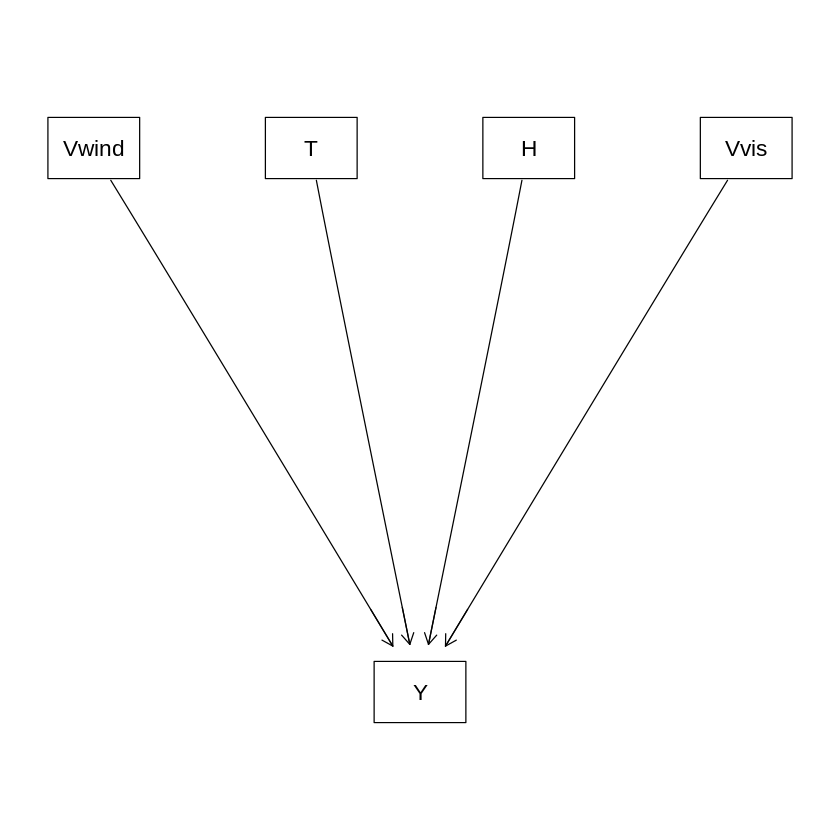

In [ ]:
can_graphviz <- requireNamespace("Rgraphviz", quietly = TRUE)
if (!can_graphviz) {
  if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
  try({ BiocManager::install("Rgraphviz", ask = FALSE, update = FALSE) }, silent = TRUE)
  can_graphviz <- requireNamespace("Rgraphviz", quietly = TRUE)
}
if (can_graphviz) {
  library(Rgraphviz)
  graphviz.plot(bn)
} else {
  if (!requireNamespace("igraph", quietly = TRUE)) install.packages("igraph")
  library(igraph)
  arcs <- bnlearn::arcs(bn)
  g_ig <- graph_from_data_frame(as.data.frame(arcs), directed = TRUE)
  plot(g_ig, vertex.size=18, vertex.label.cex=0.9, edge.arrow.size=0.4,
       main = "Estructura aprendida (alternativa igraph)")
}

**Explicación final**

**Relaciones causales:**
Las variables causales $(V_{wind},\ T,\ H,\ V_{vis})$ influyen directamente sobre la seguridad de vuelo $(Y)$.

**Aprendizaje del modelo:**
El modelo aprendido recupera correctamente la dirección de estas relaciones causales.

**Inferencia contrafactual:**
La inferencia what-if estima efectos causales puros:

$$\text{Si } V_{wind} \text{ pasa de alto a bajo} \Rightarrow P(Y = \text{seguro}) \uparrow \Delta_{pp} \text{ puntos porcentuales}$$

**Visualización y extensión:**
Los diagramas permiten visualizar la estructura causal aprendida y su posible extensión a escenarios espacio-temporales (placas o DBNs).